In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
milage_data = pd.read_csv("car_milage_in_city.csv")
emission_data = pd.read_csv("Co2_emissions.csv")

milage_data.sample(10)

,city_mpg,class,combination_mpg,cylinders,displacement,drive,fuel_type,highway_mpg,make,model,transmission,year
271,20,small sport utility vehicle,22,4.0,2.0,4wd,gas,26,jeep,cherokee trailhawk 4wd,a,2019
37,21,small sport utility vehicle,24,4.0,2.4,fwd,gas,28,jeep,patriot fwd,a,2014
56,15,large car,18,8.0,5.0,rwd,gas,23,kia,k900,a,2015
306,29,compact car,32,4.0,1.8,fwd,gas,37,toyota,corolla xle,a,2020
453,19,standard sport utility vehicle,21,4.0,2.0,4wd,gas,22,land rover,discovery,a,2023
267,23,small sport utility vehicle,26,4.0,2.0,fwd,gas,31,jeep,cherokee fwd,a,2019
135,15,two seater,18,8.0,5.0,awd,gas,23,jaguar,f-type r awd convertible,a,2016
541,23,subcompact car,27,4.0,2.0,fwd,gas,33,mini,cooper s hardtop 4 door,m,2024
47,13,standard sport utility vehicle,15,8.0,6.4,4wd,gas,19,jeep,grand cherokee srt8,a,2014
143,25,midsize car,30,6.0,3.0,awd,diesel,38,audi,a6 quattro,a,2016


### Milage Dataset Exploration

In [4]:
milage_data.describe()

,city_mpg,combination_mpg,cylinders,displacement,highway_mpg,year
count,550.000000,550.000000,548.000000,548.000000,550.000000,550.000000
mean,21.460000,24.069091,5.315693,2.931752,28.609091,2019.000000
std,8.147392,7.478369,1.759999,1.248419,6.832228,3.165156
min,11.000000,14.000000,3.000000,1.200000,18.000000,2014.000000
25%,17.000000,20.000000,4.000000,2.000000,24.000000,2016.000000
50%,20.000000,23.000000,4.000000,2.500000,28.000000,2019.000000
75%,24.000000,27.000000,6.000000,3.500000,32.000000,2022.000000
max,126.000000,112.000000,12.000000,6.800000,102.000000,2024.000000


In [5]:
milage_data.describe(include= 'object')

,class,drive,fuel_type,make,model,transmission
count,550,550,550,550,550,550
unique,13,4,3,31,276,2
top,small sport utility vehicle,awd,gas,bmw,veloster,a
freq,157,215,546,72,12,467


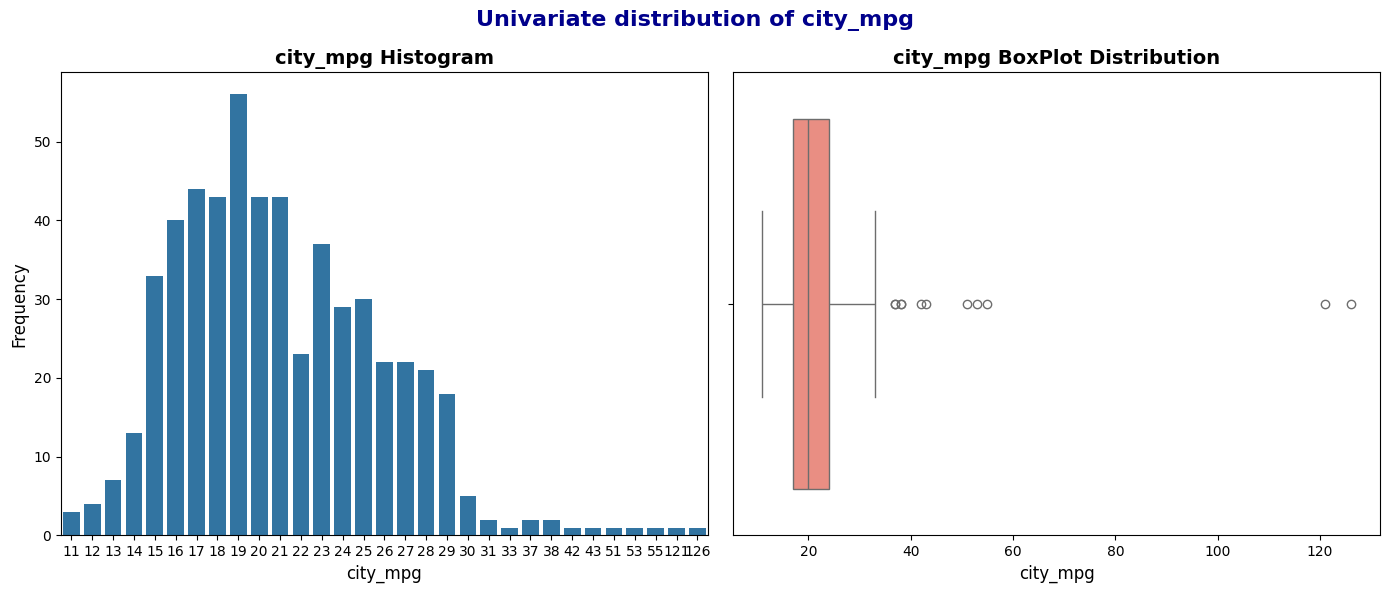

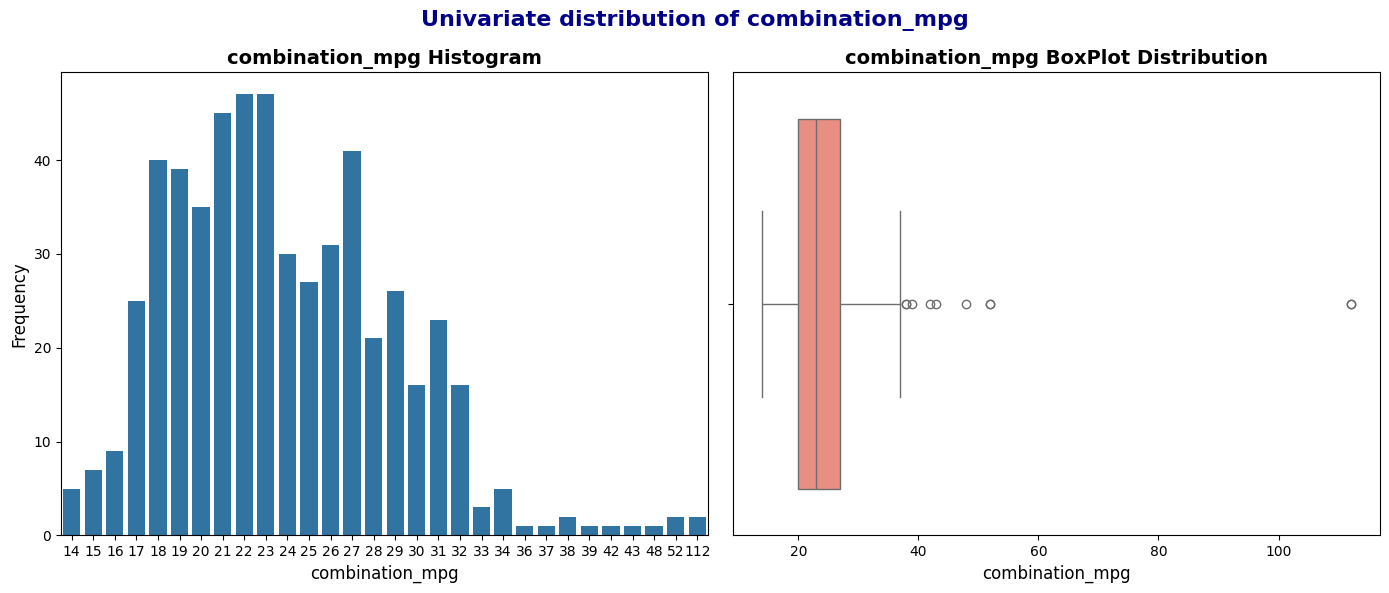

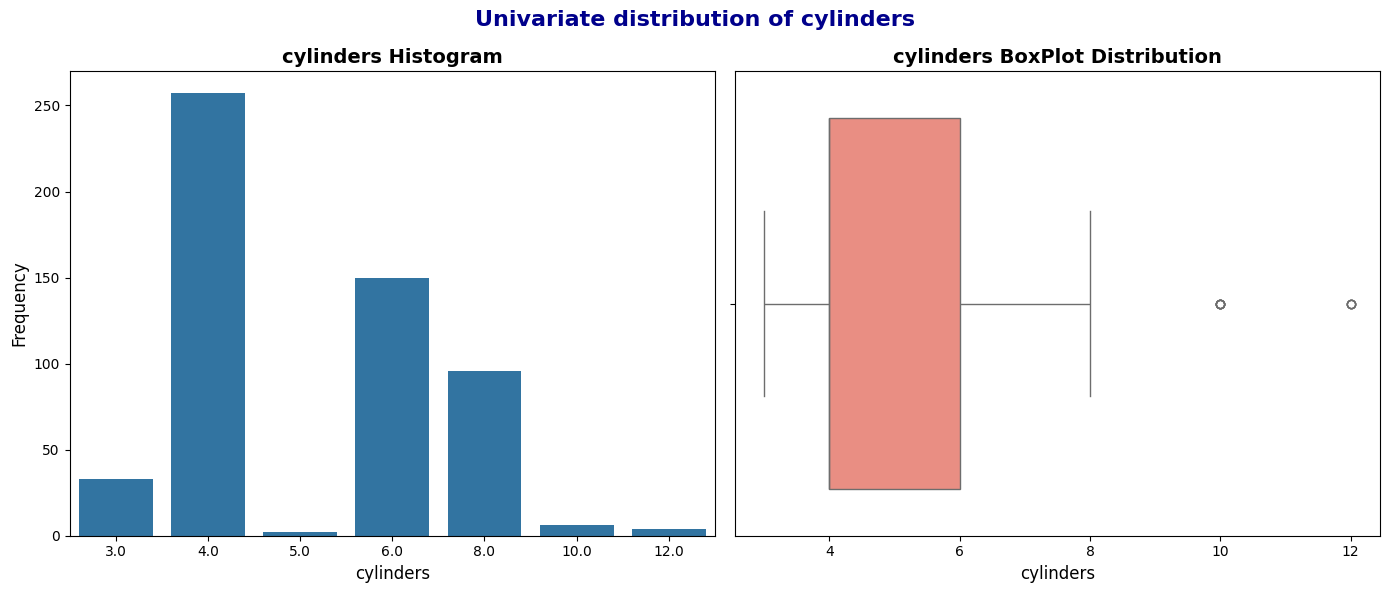

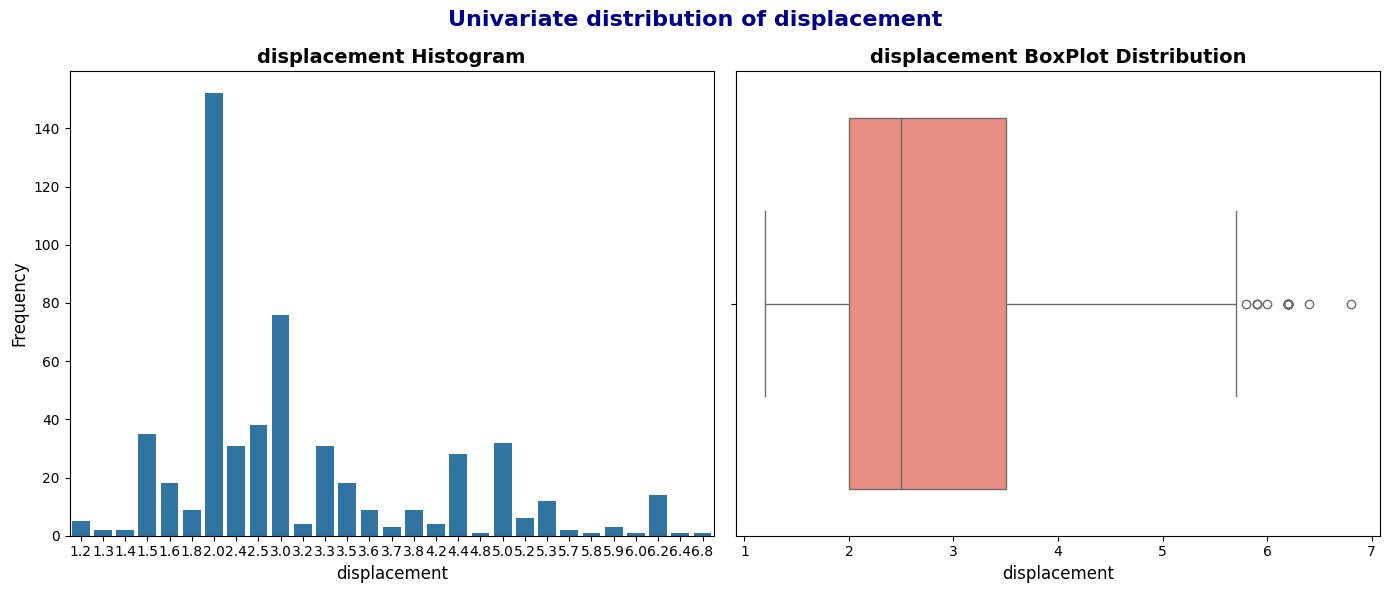

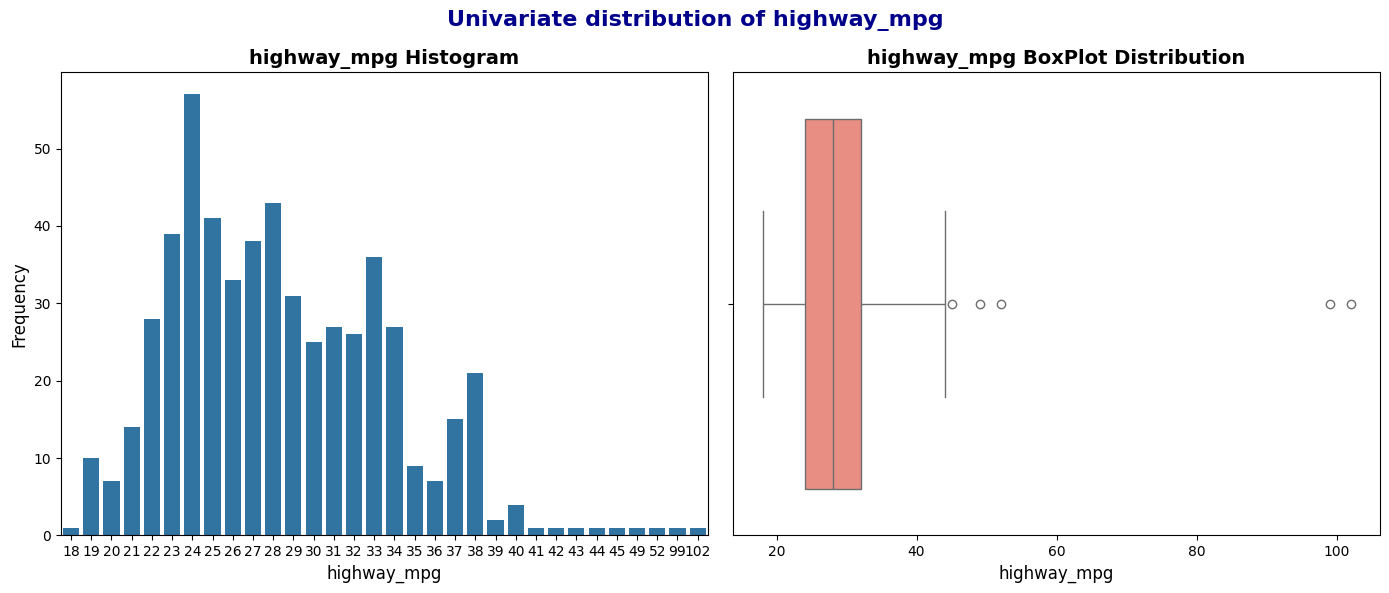

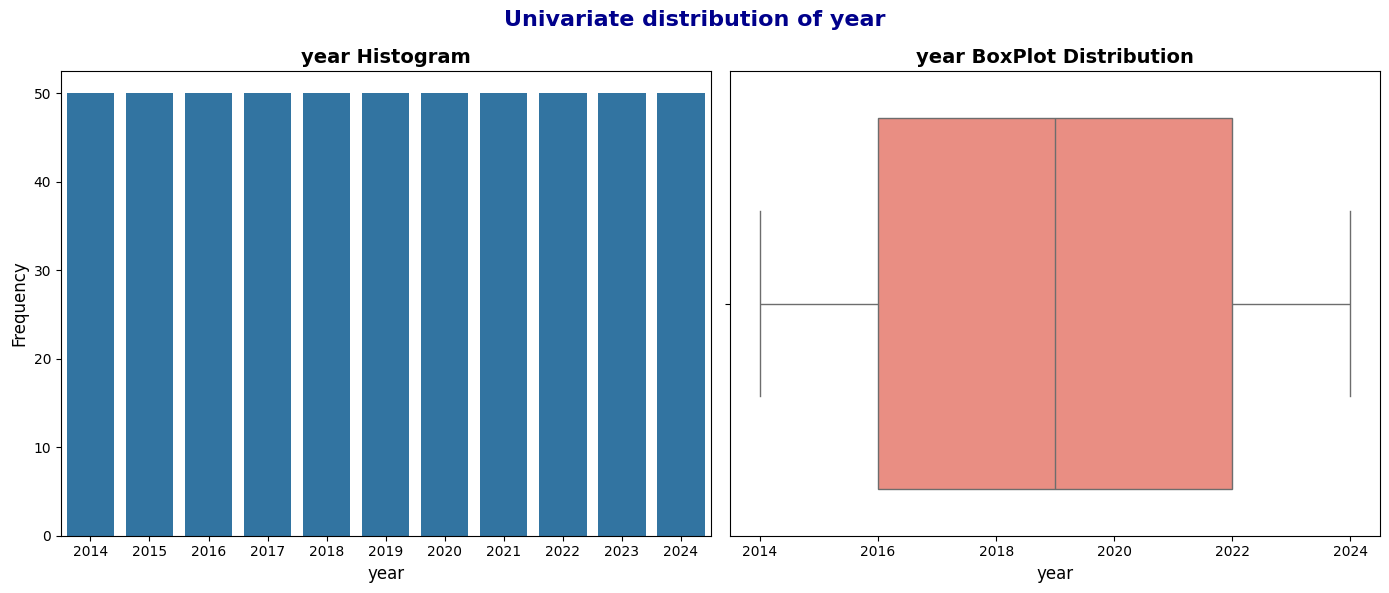

In [ ]:
numerical_columns = milage_data.select_dtypes(['int64','float64']).columns

for column in numerical_columns:
    fig, ax = plt.subplots(1,2, figsize = (14,6))
    fig.suptitle(f'Univariate distribution of {column}', fontsize=16, fontweight='bold', color='darkblue')
    
    # histogram
    sns.countplot(milage_data, x=column, ax=ax[0])
    ax[0].set_title(f'{column} Histogram', fontsize=14, fontweight='bold')
    ax[0].set_xlabel(f'{column}', fontsize=12)
    ax[0].set_ylabel('Frequency', fontsize=12)
    
    # boxplot 
    sns.boxplot(milage_data, x=column, ax=ax[1], color="salmon")
    ax[1].set_title(f'{column} BoxPlot Distribution', fontsize=14, fontweight='bold')
    ax[1].set_xlabel(f'{column}', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    print()

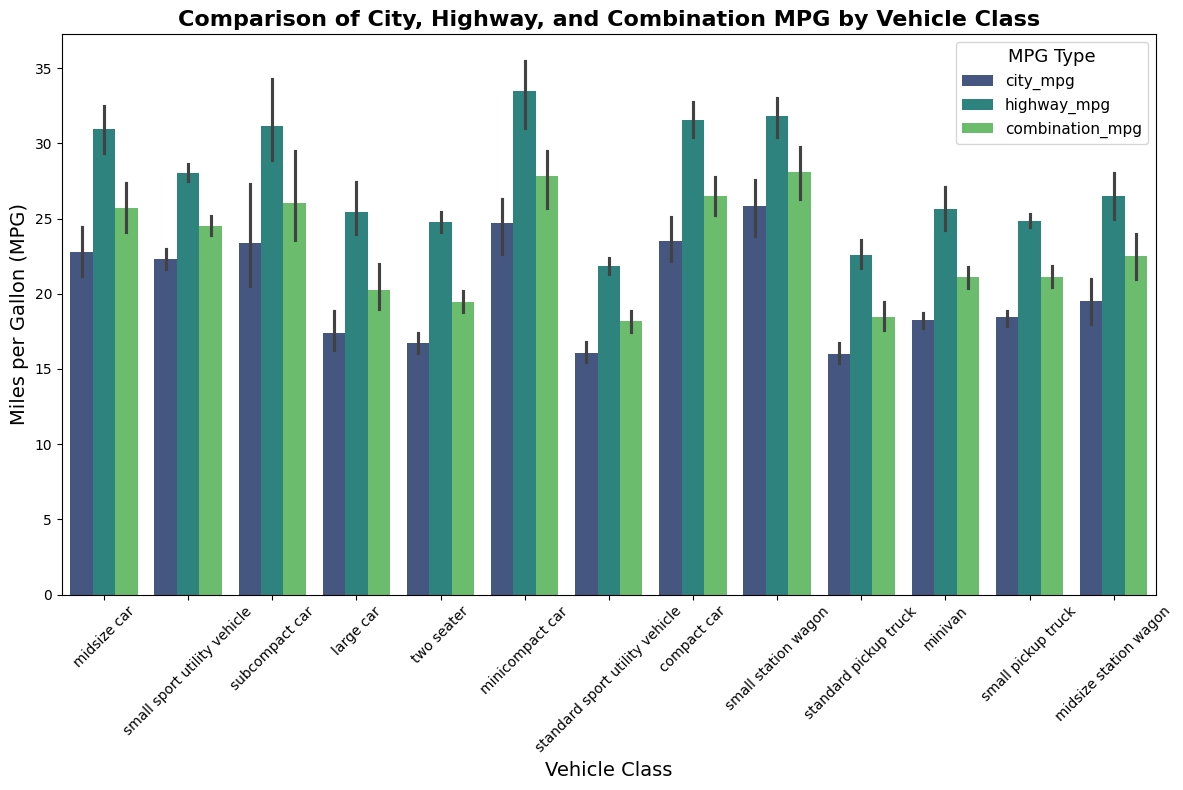

In [ ]:
df_melted = milage_data.melt(id_vars='class', value_vars=['city_mpg', 'highway_mpg', 'combination_mpg'], 
                    var_name='mpg_type', value_name='mpg')

plt.figure(figsize=(12, 8))
sns.barplot(data=df_melted, x='class', y='mpg', hue='mpg_type', palette='viridis')
plt.title("Comparison of City, Highway, and Combination MPG by Vehicle Class", fontsize=16, fontweight='bold')
plt.ylabel("Miles per Gallon (MPG)", fontsize=14)

plt.xticks(rotation = 45)
plt.xlabel("Vehicle Class", fontsize=14)
plt.legend(title="MPG Type", title_fontsize='13', fontsize='11')
plt.tight_layout()
plt.show()

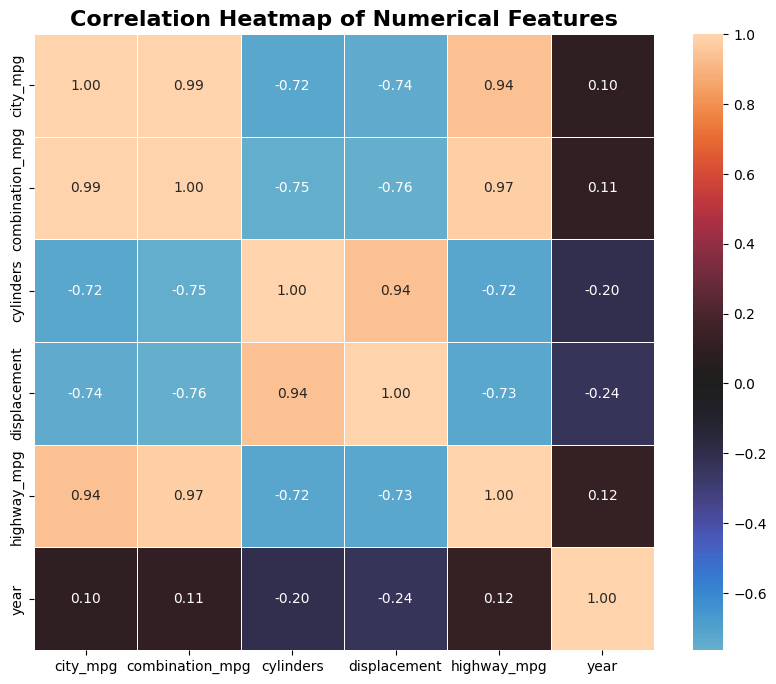

In [12]:
corr = milage_data[numerical_columns].corr()
# Crea un grafico heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, center=0, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.show()

C:\Users\vaibh\AppData\Local\Temp\ipykernel_17124\2178138979.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=milage_data, y='class', x='combination_mpg', palette='viridis', showmeans=True,


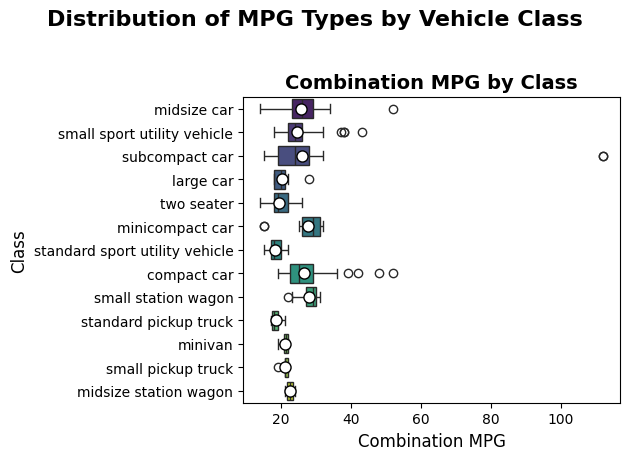

In [19]:

sns.boxplot(data=milage_data, y='class', x='combination_mpg', palette='viridis', showmeans=True, 
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
plt.title('Combination MPG by Class', fontsize=14, fontweight='bold')
plt.xlabel('Combination MPG', fontsize=12)

plt.ylabel('Class', fontsize=12)

plt.suptitle('Distribution of MPG Types by Vehicle Class', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


C:\Users\vaibh\AppData\Local\Temp\ipykernel_17124\1904584114.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=milage_data, y='drive', x='combination_mpg', palette='viridis',showmeans=True,


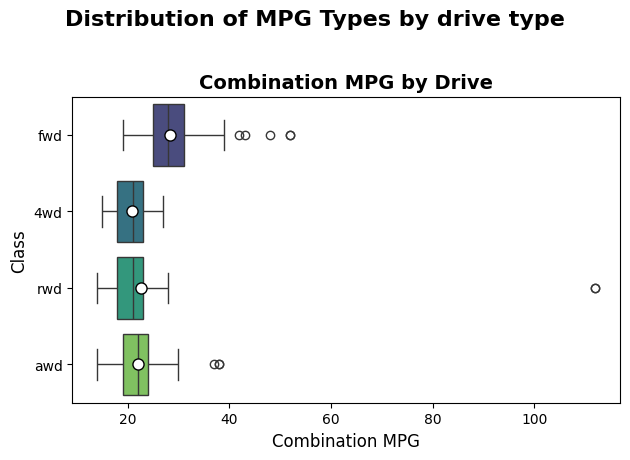

In [18]:
sns.boxplot(data=milage_data, y='drive', x='combination_mpg', palette='viridis',showmeans=True, 
            meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"})
plt.title('Combination MPG by Drive', fontsize=14, fontweight='bold')
plt.xlabel('Combination MPG', fontsize=12)

plt.ylabel('Class', fontsize=12)

plt.suptitle('Distribution of MPG Types by drive type', fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


#### EDA on Emissions Data

In [21]:
emission_data.describe()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,3.160068,5.615030,12.556534,9.041706,10.975071,27.481652,250.584699
std,1.354170,1.828307,3.500274,2.224456,2.892506,7.231879,58.512679
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,288.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [22]:
emission_data.describe(include = "object")

,Make,Model,Vehicle Class,Transmission,Fuel Type
count,7385,7385,7385,7385,7385
unique,42,2053,16,27,5
top,FORD,F-150 FFV 4X4,SUV - SMALL,AS6,X
freq,628,32,1217,1324,3637


In [28]:
emission_data.rename(columns = {'Vehicle Class': 'VehicleClass',
    'Engine Size(L)': 'EngineSize',
    'Fuel Type': 'FuelType',
    'Fuel Consumption City (L/100 km)': 'FuelConsumptionCity',
    'Fuel Consumption Hwy (L/100 km)': 'FuelConsumptionHwy',
    'Fuel Consumption Comb (L/100 km)': 'FuelConsumptionComb',
    'Fuel Consumption Comb (mpg)': 'FuelConsumptionComb_mpg',
    'CO2 Emissions(g/km)': 'Co2Emissions'}, inplace = True)

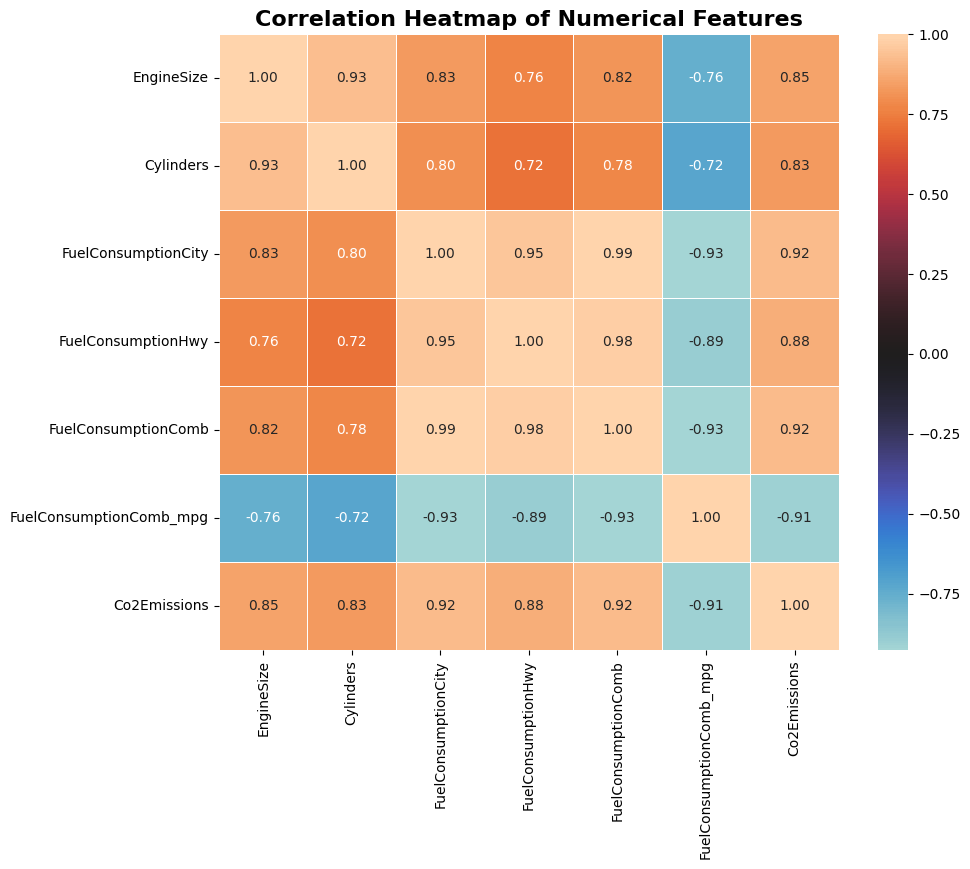

In [35]:
numerical_columns = emission_data.select_dtypes(['int64','float64']).columns
corr = emission_data[numerical_columns].corr()
# Crea un grafico heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, center=0, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16, fontweight='bold')
plt.show()

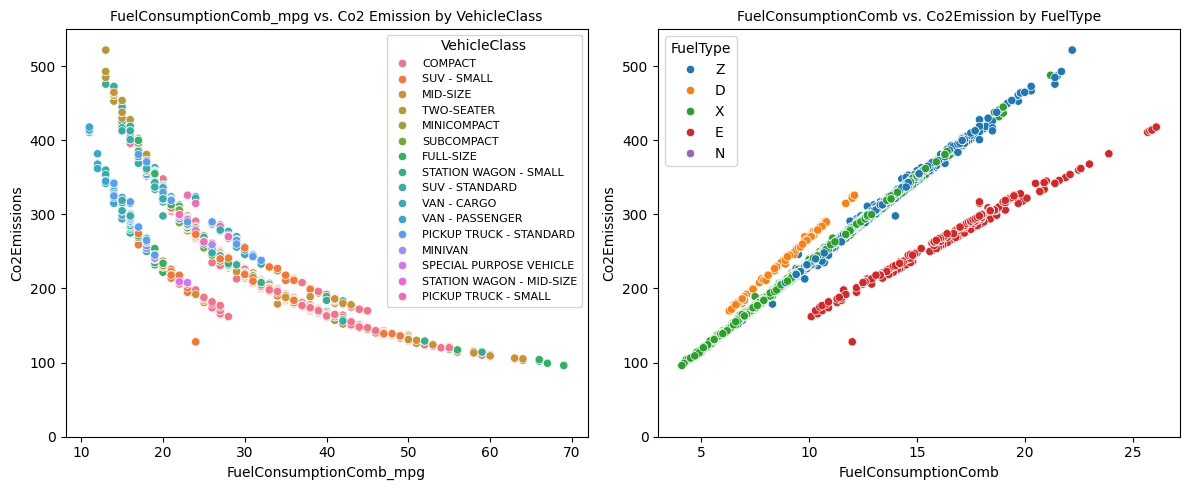

In [34]:
# Visualization with scatterplot 
fig = plt.figure(figsize=(12, 5))
ax0 = fig.add_subplot(1,2,1)
ax1 = fig.add_subplot(1,2,2)

#subplot1: scatter plot
sns.scatterplot(data=emission_data, x = "FuelConsumptionComb_mpg", y = "Co2Emissions", hue='VehicleClass', ax=ax0)
ax0.set_title("FuelConsumptionComb_mpg vs. Co2 Emission by VehicleClass", fontsize=10)
ax0.set_ylim(0, 550)
sns.move_legend(ax0, "upper right", fontsize=8.0)

#subplot2: scatter plot
sns.scatterplot(data=emission_data, x="FuelConsumptionComb", y="Co2Emissions", hue="FuelType", ax=ax1)
ax1.set_title("FuelConsumptionComb vs. Co2Emission by FuelType", fontsize=10)
ax1.set_ylim(0, 550)
sns.move_legend(ax1,"upper left")

plt.tight_layout()
plt.show()

In [3]:
import requests

# Make sure there is NO slash at the end of the URL
url = "http://127.0.0.1:8000/predict/dataset2"

payload = {
    "features": {
        "engine_size": 2.0,
        "cylinders": 4,
        "transmission_type": "Manual",
        "fuel_type": "Diesel",
        "brand": "Honda",
        "displacement": 2000.0,
        "city_kmpl": 15.0,
        "highway_kmpl": 20.0
    }
}

response = requests.post(url, json=payload)
print(f"Status Code: {response.status_code}")
print(f"Response: {response.text}")

Status Code: 404
Response: {"detail":"Not Found"}
